# 1.4 Skills: Pandas 🐼

In this notebook we will cover how to:
- work with the two main data types in `pandas`: `DataFrame` and `Series`
- work with data types in `pandas`, especially strings and dates
- load data from JSON and CSV into a `DataFrame`
- manipulate the columns of a `DataFrame`
- access data in a `DataFrame` by means of indexes and slicing

In [1]:
import pandas as pd
import numpy as np

## Creating dataframes

### From scratch

We are going to create a toy dataframe with the following shape:

|    | date                |   count | event     |
|---:|:--------------------|--------:|:----------|
|  0 | 1989-05-28 00:00:00 |    7786 | fire      |
|  1 | 1985-01-10 00:00:00 |    1688 | car_crash |
|  2 | 1980-06-28 00:00:00 |    3059 | car_crash |
|  3 | 1989-03-15 00:00:00 |    6862 | flood     |
|  4 | 1986-03-05 00:00:00 |     288 | car_crash |

In [2]:
from random import randint, choice

number_records = 1000

dates = [
    pd.Timestamp(
        choice(range(1924,2024)),
        randint(1, 12),
        randint(1, 28) # try replacing with 31 and see what happens
    )
    for i in range(0, number_records)
]

In [3]:
dates

[Timestamp('1925-06-06 00:00:00'),
 Timestamp('1973-12-28 00:00:00'),
 Timestamp('1944-05-08 00:00:00'),
 Timestamp('2000-03-21 00:00:00'),
 Timestamp('2009-12-09 00:00:00'),
 Timestamp('2010-08-24 00:00:00'),
 Timestamp('2002-09-27 00:00:00'),
 Timestamp('1950-07-18 00:00:00'),
 Timestamp('2019-01-20 00:00:00'),
 Timestamp('1943-11-21 00:00:00'),
 Timestamp('1937-10-25 00:00:00'),
 Timestamp('1983-06-27 00:00:00'),
 Timestamp('1989-10-10 00:00:00'),
 Timestamp('1984-02-19 00:00:00'),
 Timestamp('2000-05-06 00:00:00'),
 Timestamp('2007-04-03 00:00:00'),
 Timestamp('1938-10-19 00:00:00'),
 Timestamp('1974-10-05 00:00:00'),
 Timestamp('2013-07-20 00:00:00'),
 Timestamp('2006-11-06 00:00:00'),
 Timestamp('1998-12-05 00:00:00'),
 Timestamp('1948-01-26 00:00:00'),
 Timestamp('1932-08-11 00:00:00'),
 Timestamp('1928-08-23 00:00:00'),
 Timestamp('1993-12-09 00:00:00'),
 Timestamp('2020-01-11 00:00:00'),
 Timestamp('2008-09-14 00:00:00'),
 Timestamp('1937-05-26 00:00:00'),
 Timestamp('1983-05-

In [4]:
len(dates)

1000

In [5]:
counts = [
    randint(0, 10000)
    for i in range(0, number_records)
]

In [6]:
assert len(counts) == len(dates)

In [7]:
event_types = ["fire", "flood", "car_crash", "plane_crash"]
events = [
    np.random.choice(event_types)
    for i in range(0, number_records)
]

In [8]:
events

[np.str_('fire'),
 np.str_('plane_crash'),
 np.str_('flood'),
 np.str_('flood'),
 np.str_('car_crash'),
 np.str_('fire'),
 np.str_('flood'),
 np.str_('flood'),
 np.str_('plane_crash'),
 np.str_('flood'),
 np.str_('plane_crash'),
 np.str_('flood'),
 np.str_('flood'),
 np.str_('flood'),
 np.str_('plane_crash'),
 np.str_('car_crash'),
 np.str_('fire'),
 np.str_('fire'),
 np.str_('plane_crash'),
 np.str_('flood'),
 np.str_('car_crash'),
 np.str_('fire'),
 np.str_('flood'),
 np.str_('plane_crash'),
 np.str_('fire'),
 np.str_('plane_crash'),
 np.str_('fire'),
 np.str_('car_crash'),
 np.str_('car_crash'),
 np.str_('plane_crash'),
 np.str_('car_crash'),
 np.str_('plane_crash'),
 np.str_('plane_crash'),
 np.str_('plane_crash'),
 np.str_('fire'),
 np.str_('plane_crash'),
 np.str_('flood'),
 np.str_('flood'),
 np.str_('plane_crash'),
 np.str_('flood'),
 np.str_('plane_crash'),
 np.str_('plane_crash'),
 np.str_('car_crash'),
 np.str_('plane_crash'),
 np.str_('fire'),
 np.str_('fire'),
 np.str_('fi

In [9]:
assert len(events) == len(counts) == len(dates)

In [10]:
toy_df = pd.DataFrame({
    "date": dates,
    "count": counts,
    "event": events
})

In [11]:
#toy_df.head(10)
toy_df.tail(10)
#toy_df.sample(10)

,date,count,event
990,1966-04-24,2625,flood
991,1933-07-15,480,flood
992,1998-12-14,8526,flood
993,1969-06-16,974,flood
994,1993-02-02,8071,plane_crash
995,1998-02-27,3013,car_crash
996,1979-10-22,4068,flood
997,2004-08-27,433,plane_crash
998,1945-07-06,1419,plane_crash
999,1985-05-16,8282,plane_crash


In [57]:
len(toy_df)

1000

In [60]:
toy_df.iloc[990]

date     1959-08-22 00:00:00
count                   4226
event                  flood
Name: 990, dtype: object

**Try out**: what happens if you change the length of either of the two lists? Try e.g. passing 20 dates instead of 10.

In [ ]:
# instead of a dictionary of lists, you can pass
# a dictionary of `pandas.Series`. The result is the same.

toy_df = pd.DataFrame(
    {
        "date": pd.Series(dates),
        "count": pd.Series(counts),
        "event": pd.Series(events)
    }
)

In [ ]:
toy_df

In [ ]:
toy_df.info()

In [ ]:
# a df is a collection of series
# each column is a series

type(toy_df.date)

### By loading (local) data

Dataframe can be created from scratch as we did above, but most often they are created by loading existing data into a dataframe by means of `pandas`' input/oputput methods.

#### From JSON

Loading data from a JSON file is very similar to creating a `DataFrame` from a `dict`.

This is how one would do it in pure Python:

In [66]:
import json
json_file_path = '../data/bl_books/sample/book_data_sample.json'

# JSON data gets read into a dictionary

with open(json_file_path, 'r') as jsonfile:
    json_data = json.load(jsonfile)
    
books_df = pd.DataFrame(json_data)

Since reading from files is a very common operation in any data analysis workflow, `pandas` provides methods to read from a variety of formats (JSON, CSV, clipboard, etc.)

The block of code above can be replaced by the following one-liner:

In [67]:
books_df = pd.read_json(json_file_path)

/var/folders/g_/f12m6prx6_54vv77tghqx5xw0000gq/T/ipykernel_17316/3298360895.py:1: FutureWarning: The behavior of 'to_datetime' with 'unit' when parsing strings is deprecated. In a future version, strings will be parsed as datetime strings, matching the behavior without a 'unit'. To retain the old behavior, explicitly cast ints or floats to numeric type before calling to_datetime.
  books_df = pd.read_json(json_file_path)


In [68]:
books_df.head(2)

,datefield,shelfmarks,publisher,title,edition,flickr_url_to_book_images,place,issuance,authors,date,pdf,identifier,corporate,fulltext_filename,imgs
0,1841,[British Library HMNTS 11601.ddd.2.],Privately printed,"[The Poetical Aviary, with a bird's-eye view o...",,http://www.flickr.com/photos/britishlibrary/ta...,Calcutta,monographic,{'creator': ['A. A.']},1970-01-01 00:30:41,{'1': 'lsidyv35c55757'},196,{},sample/full_texts/000000196_01_text.json,NaN
1,1888,[British Library HMNTS 9025.cc.14.],Rivingtons,[A History of Greece. Part I. From the earlies...,,http://www.flickr.com/photos/britishlibrary/ta...,London,monographic,"{'creator': ['Abbott, Evelyn']}",1970-01-01 00:31:28,{'1': 'lsidyv376da437'},4047,{},sample/full_texts/000004047_01_text.json,{'0': {'000257': ['11104648374']}}


In [69]:
books_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 452 entries, 0 to 451
Data columns (total 15 columns):
 #   Column                     Non-Null Count  Dtype         
---  ------                     --------------  -----         
 0   datefield                  452 non-null    object        
 1   shelfmarks                 452 non-null    object        
 2   publisher                  452 non-null    object        
 3   title                      452 non-null    object        
 4   edition                    452 non-null    object        
 5   flickr_url_to_book_images  452 non-null    object        
 6   place                      452 non-null    object        
 7   issuance                   452 non-null    object        
 8   authors                    452 non-null    object        
 9   date                       450 non-null    datetime64[ns]
 10  pdf                        452 non-null    object        
 11  identifier                 452 non-null    int64         
 12  corporat

**NB**: note the number of missing values for the `books_df.imgs` (n=172).

#### From CSV

Similarly to `pandas.read_json()`, `pandas.read_csv()` is there to make your life easier when it comes to loading CSV data into a dataframe (and that happens very often!).

Let's import one of the CSV files from the "Venice Apprenticeship" dataset (`../data/apprenticeship_venice/`).

In [71]:
csv_file_path = '../data/apprenticeship_venice/professions_data.csv'

In [72]:
garzoni_df = pd.read_csv(csv_file_path)

ParserError: Error tokenizing data. C error: Expected 7 fields in line 36, saw 8


Why it did not work??

Let's have a look at the file first...

In [73]:
!head -n 2 ../data/apprenticeship_venice/professions_data.csv

page_title;register;annual_salary;a_profession;profession_code_strict;profession_code_gen;profession_cat;corporation;keep_profession_a;complete_profession_a;enrolmentY;enrolmentM;startY;startM;length;has_fled;m_profession;m_profession_code_strict;m_profession_code_gen;m_profession_cat;m_corporation;keep_profession_m;complete_profession_m;m_gender;m_name;m_surname;m_patronimic;m_atelier;m_coords;a_name;a_age;a_gender;a_geo_origins;a_geo_origins_std;a_coords;a_quondam;accommodation_master;personal_care_master;clothes_master;generic_expenses_master;salary_in_kind_master;pledge_goods_master;pledge_money_master;salary_master;female_guarantor;period_cat;incremental_salary
Carlo Della sosta (Orese) 1592-08-03;asv, giustizia vecchia, accordi dei garzoni, 114, 155;NA;orese;orese;orefice;orefice;Oresi;1;1;1592;08;1592;08;3;0;orese;orese;orefice;orefice;Oresi;1;1;1;Zuan Battista;Amigoni;;;0, 0;Carlo Della sosta;17;1;;;0, 0;1;0;1;1;1;0;0;0;0;0;NA;0


More than a comma-separated value, it looks like semicolon-separated values...

In [74]:
# the `sep` input parameter
# allows us to specify which character/symbol is used
# to separate column values

garzoni_df = pd.read_csv(
    csv_file_path,
    sep=';'
)

**NB**: There may be invalid lines in the data you are reading in. `read_csv()` puts you in full control of that: by setting the param `on_bad_lines` to `warn` we tell `pandas` to warn us bout bad lines and skip them (see [docs](https://pandas.pydata.org/docs/reference/api/pandas.read_csv.html)). If no warning is return, then your csv is well-formed.

In [ ]:
garzoni_df = pd.read_csv(
    csv_file_path,
    sep=';',
    on_bad_lines="warn",
)

In [78]:
garzoni_df.shape

(9653, 47)

In [79]:
toy_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 3 columns):
 #   Column  Non-Null Count  Dtype         
---  ------  --------------  -----         
 0   date    1000 non-null   datetime64[ns]
 1   count   1000 non-null   int64         
 2   event   1000 non-null   object        
dtypes: datetime64[ns](1), int64(1), object(1)
memory usage: 23.6+ KB


In [77]:
garzoni_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9653 entries, 0 to 9652
Data columns (total 47 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   page_title                9653 non-null   object 
 1   register                  9653 non-null   object 
 2   annual_salary             7870 non-null   float64
 3   a_profession              9653 non-null   object 
 4   profession_code_strict    9618 non-null   object 
 5   profession_code_gen       9614 non-null   object 
 6   profession_cat            9597 non-null   object 
 7   corporation               9350 non-null   object 
 8   keep_profession_a         9653 non-null   int64  
 9   complete_profession_a     9653 non-null   int64  
 10  enrolmentY                9628 non-null   float64
 11  enrolmentM                9631 non-null   float64
 12  startY                    9533 non-null   float64
 13  startM                    9539 non-null   float64
 14  length  

In [76]:
garzoni_df.sample(5)

,page_title,register,annual_salary,a_profession,profession_code_strict,profession_code_gen,profession_cat,corporation,keep_profession_a,complete_profession_a,...,personal_care_master,clothes_master,generic_expenses_master,salary_in_kind_master,pledge_goods_master,pledge_money_master,salary_master,female_guarantor,period_cat,incremental_salary
5703,Zuan Battista di Scagni (frutariol) 1622-07-12,"asv, giustizia vecchia, accordi dei garzoni, 1...",4.000000,frutariol,frutariol,venditori di frutta,venditori di frutta,Frutaroli,1,1,...,1,0,1,0,0,0,1,1,1.0,0
9282,Faustin Guera (bolzer) 1621-10-19,"asv, giustizia vecchia, accordi dei garzoni, 1...",NaN,bolzer,bolzer,fabbricatore di valigie e bauli,fabbricatore di valigie e bauli,Bolzeri,1,1,...,1,0,1,0,0,0,0,0,NaN,0
6375,Zuane Sermisi (pittor) 1645-12-20,"asv, giustizia vecchia, accordi dei garzoni, 1...",3.571429,pittor,pitor,pittore,pittore,Pittori,1,1,...,0,0,1,0,0,0,1,0,1.0,0
7494,Francesco Della pertega (Indorador) 1584-03-20,"asv, giustizia vecchia, accordi dei garzoni, 1...",3.142857,indorador,indorador,indoratore,indoratore,Indoratori,1,1,...,1,0,1,0,0,0,1,0,1.0,0
9347,Giacomo dei Cacosi (tesser da mantili) 1621-01-21,"asv, giustizia vecchia, accordi dei garzoni, 1...",2.222222,tesser da mantilli,tesser da mantilli,tessitore - diverse specializzazioni,tessitore,Tesseri,1,1,...,1,0,1,0,0,0,1,0,1.0,0


<div class="alert alert-info">
    <b>More format readers</b>
    <p></p>
    Pandas supports more formats than just CSV and JSON. See the library's <a href="https://pandas.pydata.org/pandas-docs/stable/user_guide/io.html">documentation</a> for the full list of supported formats.
</div>

### By loading (remote) data

In [109]:
textent_metadata_df = pd.read_csv('https://raw.githubusercontent.com/TextEnt/chrono-spatial-processing/refs/heads/main/data/groundtruth/textent-annotations%20-%20sample-metadata.tsv', sep='\t')

In [110]:
textent_annotations_df = pd.read_csv('https://raw.githubusercontent.com/TextEnt/chrono-spatial-processing/refs/heads/main/data/groundtruth/textent-annotations%20-%20groundtruth-annotations.tsv', sep='\t')

In [111]:
textent_metadata_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 70 entries, 0 to 69
Data columns (total 11 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   document_id       70 non-null     object 
 1   author            65 non-null     object 
 2   title             70 non-null     object 
 3   annotated         70 non-null     bool   
 4   exclude           70 non-null     bool   
 5   keep_fine_tuning  70 non-null     bool   
 6   publication_date  70 non-null     int64  
 7   document_length   70 non-null     int64  
 8   link              60 non-null     object 
 9   link_OCR          70 non-null     object 
 10  notes             0 non-null      float64
dtypes: bool(3), float64(1), int64(2), object(5)
memory usage: 4.7+ KB


In [112]:
textent_annotations_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 70 entries, 0 to 69
Data columns (total 15 columns):
 #   Column                    Non-Null Count  Dtype 
---  ------                    --------------  ----- 
 0   document_id               70 non-null     object
 1   author                    65 non-null     object
 2   title                     70 non-null     object
 3   period                    68 non-null     object
 4   period_reason             68 non-null     object
 5   timeframe_start           68 non-null     object
 6   timeframe_end             68 non-null     object
 7   preferred_location        68 non-null     object
 8   accepted_locations        68 non-null     object
 9   location_reason           67 non-null     object
 10  preferred_location_QID    66 non-null     object
 11  acceptable_location_QIDs  62 non-null     object
 12  Anthology                 70 non-null     object
 13  Unnamed: 13               4 non-null      object
 14  Unnamed: 14               3 

In [89]:
textent_annotations_df['Unnamed: 13']

0     NaN
1     NaN
2     NaN
3     NaN
4     NaN
     ... 
65    NaN
66    NaN
67    NaN
68    NaN
69    NaN
Name: Unnamed: 13, Length: 70, dtype: object

In [93]:
textent_annotations_df.drop(columns=['Unnamed: 13', 'Unnamed: 14'], inplace=True)

In [95]:
textent_annotations_df.columns

Index(['document_id', 'author', 'title', 'period', 'period_reason',
       'timeframe_start', 'timeframe_end', 'preferred_location',
       'accepted_locations', 'location_reason', 'preferred_location_QID',
       'acceptable_location_QIDs', 'Anthology'],
      dtype='object')

In [96]:
textent_metadata_df.reset_index(drop=True, inplace=False)

,document_id,author,title,annotated,exclude,keep_fine_tuning,publication_date,document_length,link,link_OCR,notes
0,bpt6k5745752g,"Boissin de Gallardon, Jean",Les tragédies et histoires saintes de Jean Boi...,False,True,False,1618,338338,http://catalogue.bnf.fr/ark:/12148/cb30122385g,https://github.com/TextEnt/chrono-spatial-proc...,NaN
1,bpt6k5752605t,"Hauteroche, Noël Lebreton",Les bourgeoises de qualité . Comedie. Par Mr d...,True,False,False,1691,103493,http://catalogue.bnf.fr/ark:/12148/cb30582284s,https://github.com/TextEnt/chrono-spatial-proc...,NaN
2,bpt6k852919x,NaN,Le Mariage de Fine-Epice. Comédie,True,False,False,1664,134035,http://catalogue.bnf.fr/ark:/12148/cb39325270g,https://github.com/TextEnt/chrono-spatial-proc...,NaN
3,bpt6k12804007,Molière,"Sganarelle ou le Cocu imaginaire, comédie avec...",True,False,False,1662,67710,http://catalogue.bnf.fr/ark:/12148/cb38650865b,https://github.com/TextEnt/chrono-spatial-proc...,NaN
4,bpt6k5772310n,"Corneille, Thomas","Ariane , tragédie. Par T. Corneille",True,False,False,1672,76240,http://catalogue.bnf.fr/ark:/12148/cb30272162g,https://github.com/TextEnt/chrono-spatial-proc...,NaN
...,...,...,...,...,...,...,...,...,...,...,...
65,bpt6k62514727,"Villiers, Claude Deschamps",Les ramonneurs. Comédie . Comédie. Par Mr de V...,True,False,False,1662,63178,NaN,https://github.com/TextEnt/chrono-spatial-proc...,NaN
66,bpt6k12804415,Molière,"La Critique de l'Escole des femmes, comedie. P...",True,False,False,1663,49436,NaN,https://github.com/TextEnt/chrono-spatial-proc...,NaN
67,bpt6k8528543,"La Motte, de.","Le Grand Magus, Tragi-Comédie",True,False,False,1656,92787,NaN,https://github.com/TextEnt/chrono-spatial-proc...,NaN
68,bpt6k5772699f,"Charenton, De","La mort de Baltazar, roy de Babilone , tragédi...",True,False,True,1662,82484,NaN,https://github.com/TextEnt/chrono-spatial-proc...,NaN


In [84]:
textent_annotations_df.sample(5)

,document_id,author,title,period,period_reason,timeframe_start,timeframe_end,preferred_location,accepted_locations,location_reason,preferred_location_QID,acceptable_location_QIDs,Anthology,Unnamed: 13,Unnamed: 14
18,btv1b8622099v,"Rotrou, Jean de",Clorinde : comédie/de Rotrou,Early modern,- This is a comedy - Name of the characters - ...,1600,1637,Paris,Paris | France,- Paris is mentioned - Characters have French ...,Q90,Q90 | Q142,No,NaN,NaN
42,bpt6k1519298v,"Chevalier, Jean",La disgrâce des domestiques : comédie représen...,Early modern,- This is a comedy - Name of the characters - ...,1600,1662,Paris,Paris | France,- Place is probable - This is a comedy - Publi...,Q90,Q90 | Q142,No,NaN,NaN
31,bpt6k5651559g,NaN,Dialogue du cardinal de Richelieu voulant entr...,Early modern,- Historical character: Richelieu - Just after...,1642,1642,Hell and paradise,Hell and paradise,- Hell and paradise are mentioned,NaN,Q564 | Q3363340,No,NaN,NaN
32,bpt6k1090155z,"Rotrou, Jean de","Les Sosies, comédie",Ancient Greece,"- Roman gods (Juno, Jupiter, Mercury) - Greek ...",-1350,-1200,Greece,Greece,- Greek myth of Amphitryon and Alcmene - Greek...,Q41,Q41,No,NaN,NaN
49,bpt6k1090060x,"Millet, Jean",Pastorale et tragi-comedie de Janin,Early modern,- Name of the characters (Janin) - Grenoble is...,1600,1692,Grenoble,Grenoble | France,- Grenoble is mentioned,Q1289,Q1289 | Q142,No,NaN,NaN


## Exploring a dataframe

In [97]:
toy_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 3 columns):
 #   Column  Non-Null Count  Dtype         
---  ------  --------------  -----         
 0   date    1000 non-null   datetime64[ns]
 1   count   1000 non-null   int64         
 2   event   1000 non-null   object        
dtypes: datetime64[ns](1), int64(1), object(1)
memory usage: 23.6+ KB


In [98]:
garzoni_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9653 entries, 0 to 9652
Data columns (total 47 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   page_title                9653 non-null   object 
 1   register                  9653 non-null   object 
 2   annual_salary             7870 non-null   float64
 3   a_profession              9653 non-null   object 
 4   profession_code_strict    9618 non-null   object 
 5   profession_code_gen       9614 non-null   object 
 6   profession_cat            9597 non-null   object 
 7   corporation               9350 non-null   object 
 8   keep_profession_a         9653 non-null   int64  
 9   complete_profession_a     9653 non-null   int64  
 10  enrolmentY                9628 non-null   float64
 11  enrolmentM                9631 non-null   float64
 12  startY                    9533 non-null   float64
 13  startM                    9539 non-null   float64
 14  length  

In [99]:
textent_metadata_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 70 entries, 0 to 69
Data columns (total 11 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   document_id       70 non-null     object 
 1   author            65 non-null     object 
 2   title             70 non-null     object 
 3   annotated         70 non-null     bool   
 4   exclude           70 non-null     bool   
 5   keep_fine_tuning  70 non-null     bool   
 6   publication_date  70 non-null     int64  
 7   document_length   70 non-null     int64  
 8   link              60 non-null     object 
 9   link_OCR          70 non-null     object 
 10  notes             0 non-null      float64
dtypes: bool(3), float64(1), int64(2), object(5)
memory usage: 4.7+ KB


## Summary statistics

In [101]:
toy_df.describe()

,date,count
count,1000,1000.000000
mean,1972-11-10 06:07:12,4901.504000
min,1924-05-21 00:00:00,2.000000
25%,1947-01-11 18:00:00,2392.250000
50%,1971-06-30 12:00:00,4850.500000
75%,1999-09-10 18:00:00,7339.750000
max,2023-10-25 00:00:00,9998.000000
std,NaN,2924.883256


In [104]:
textent_metadata_df.document_length.describe()

count        70.000000
mean      89746.842857
std       72756.409720
min       11922.000000
25%       57541.500000
50%       82399.500000
75%      100456.500000
max      541424.000000
Name: document_length, dtype: float64

In [112]:
average_length = textent_metadata_df.document_length.describe()['mean']

In [116]:
filter = textent_metadata_df['document_length'] > average_length

In [123]:
df_filtered = textent_metadata_df[filter]

In [124]:
df_filtered.info()

<class 'pandas.core.frame.DataFrame'>
Index: 27 entries, 0 to 67
Data columns (total 11 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   document_id       27 non-null     object 
 1   author            26 non-null     object 
 2   title             27 non-null     object 
 3   annotated         27 non-null     bool   
 4   exclude           27 non-null     bool   
 5   keep_fine_tuning  27 non-null     bool   
 6   publication_date  27 non-null     int64  
 7   document_length   27 non-null     int64  
 8   link              25 non-null     object 
 9   link_OCR          27 non-null     object 
 10  notes             0 non-null      float64
dtypes: bool(3), float64(1), int64(2), object(5)
memory usage: 2.0+ KB


In [102]:
toy_df.describe(include='all')

,date,count,event
count,1000,1000.000000,1000
unique,NaN,NaN,4
top,NaN,NaN,plane_crash
freq,NaN,NaN,257
mean,1972-11-10 06:07:12,4901.504000,NaN
min,1924-05-21 00:00:00,2.000000,NaN
25%,1947-01-11 18:00:00,2392.250000,NaN
50%,1971-06-30 12:00:00,4850.500000,NaN
75%,1999-09-10 18:00:00,7339.750000,NaN
max,2023-10-25 00:00:00,9998.000000,NaN


In [ ]:
toy_df['count'].describe()

In [ ]:
textent_metadata_df.info()

In [ ]:
# textent_metadata_df.describe(include='all')
textent_metadata_df.describe()

In [ ]:
textent_metadata_df['document_length'].describe()

## Selecting columns

In [ ]:
toy_df

In [ ]:
toy_df['event']

In [ ]:
# column selection is an indirect way of dropping columns from a dataframe
toy_df[['event', 'count']]

In [ ]:
# column selection can be used also to reorder columns
toy_df[['count', 'event', 'date']]

## Filtering columns

In [12]:
toy_df[toy_df['count'] < 100]

,date,count,event
163,1958-07-12,91,flood
338,1932-09-20,42,flood
566,2010-10-26,69,car_crash
575,2023-03-12,19,flood
598,1993-03-12,36,car_crash
608,2006-06-06,68,car_crash
632,1950-09-05,50,plane_crash
880,1958-04-15,51,flood


In [13]:
toy_df[toy_df['count'] < 50]

,date,count,event
338,1932-09-20,42,flood
575,2023-03-12,19,flood
598,1993-03-12,36,car_crash


In [14]:
# how many events are there in total?
int(toy_df['count'].sum())

4920882

In [18]:
toy_df['year'] = toy_df.date.dt.year

In [19]:
# how many events are there in 1982?
int(toy_df[toy_df['year']==1982]['count'].sum())

34113

In [20]:
toy_df[toy_df.event == 'fire']['count'].sum()

np.int64(1210284)

## Counting values

In [21]:
# count number of events by type
toy_df.event.value_counts()

event
plane_crash    266
fire           249
car_crash      248
flood          237
Name: count, dtype: int64

In [22]:
toy_df['year'] = toy_df.date.dt.year

In [23]:
# count number of events by year
toy_df.date.dt.year.value_counts()

date
1956    18
2005    16
2019    15
1943    15
2023    15
        ..
1974     5
1981     5
1977     4
1949     4
1934     2
Name: count, Length: 100, dtype: int64

In [24]:
# count number of events by year
toy_df.date.dt.year.value_counts(normalize=True)

date
1956    0.018
2005    0.016
2019    0.015
1943    0.015
2023    0.015
        ...  
1974    0.005
1981    0.005
1977    0.004
1949    0.004
1934    0.002
Name: proportion, Length: 100, dtype: float64

In [25]:
# yes, head and tail methods work on series too
# here we keep only the top-5 years with the most events 
toy_df.date.dt.year.value_counts().head(5)

date
1956    18
2005    16
2019    15
1943    15
2023    15
Name: count, dtype: int64

In [27]:
toy_df.event.value_counts().to_frame().sort_values('count', ascending=False)

,count
event,
plane_crash,266
fire,249
car_crash,248
flood,237


## Plotting

<Axes: ylabel='Frequency'>

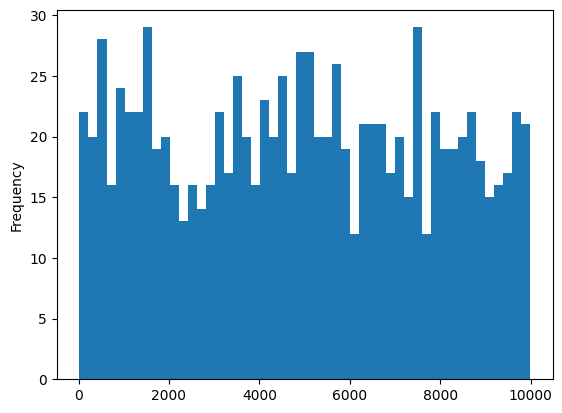

In [ ]:
toy_df['count'].plot(kind='hist', bins=50)

In [163]:
pd.pivot_table(
    toy_df,
    columns='event',
    values='count',
    aggfunc='sum'
).T

,count
event,
car_crash,1265713
fire,1210284
flood,1185789
plane_crash,1259096


<Axes: title={'center': 'Total number of events by type'}, xlabel='event'>

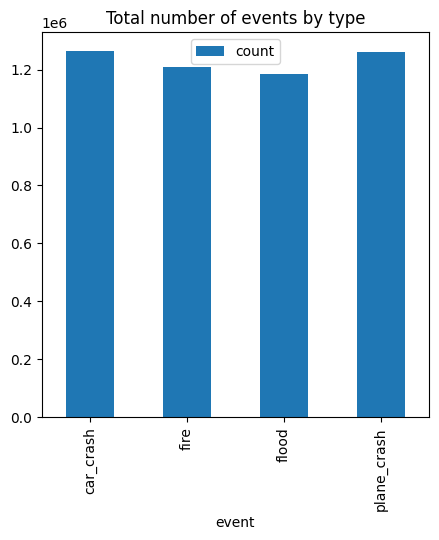

In [168]:
pd.pivot_table(
    toy_df,
    columns='event',
    values='count',
    aggfunc='sum'
).T.plot(
    kind='bar',
    figsize=(5, 5),
    title='Total number of events by type'
)

<Axes: xlabel='decade', ylabel='count'>

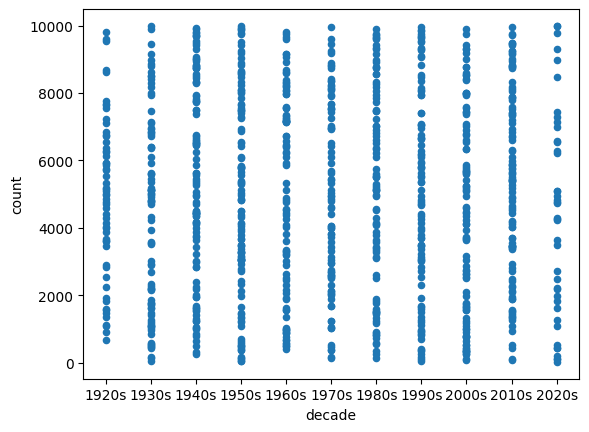

In [169]:
toy_df.sort_values('year').plot.scatter(
    x='decade',
    y='count',
)

## Understanding the distribution of a variable

In [80]:
# this cell is quite complex, so let's break it down
toy_df['decade'] = toy_df.date.map(lambda x: f"{str(x.year)[:-1]}0s")

In [81]:
toy_df[['decade', 'count']]

,decade,count
0,1920s,6132
1,1970s,8157
2,1940s,1630
3,2000s,763
4,2000s,6348
...,...,...
995,1990s,3013
996,1970s,4068
997,2000s,433
998,1940s,1419


In [82]:
df_events_by_decade = pd.pivot_table(
    toy_df,
    index=['decade'],
    values=['count'],
    aggfunc='sum'
)

<Axes: title={'center': 'Number of events by decade'}, xlabel='decade'>

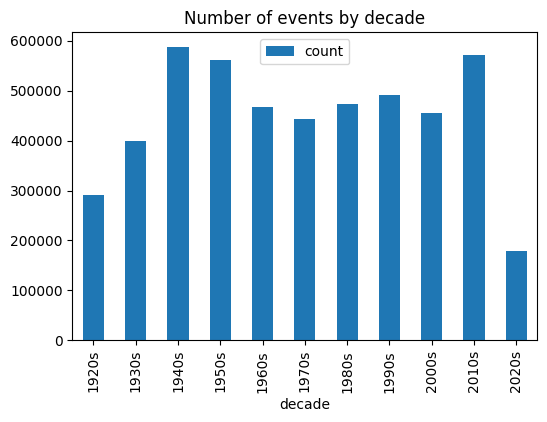

In [83]:
df_events_by_decade.plot(kind='bar', figsize=(6, 4), title='Number of events by decade')

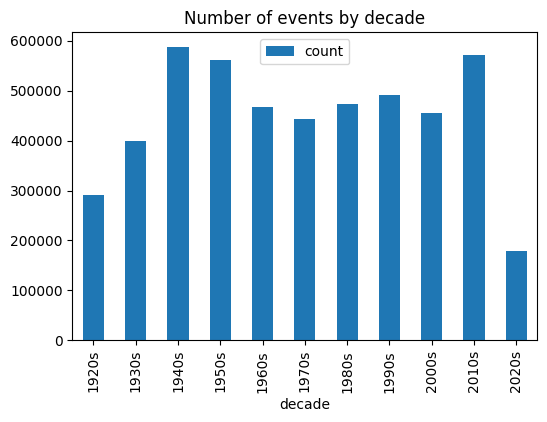

In [145]:
ax = df_events_by_decade.plot(kind='bar', figsize=(6, 4), title='Number of events by decade')
ax.figure.savefig('../data/toydf_plot.pdf')
ax.figure.savefig('../data/toydf_plot.png')

<Axes: >

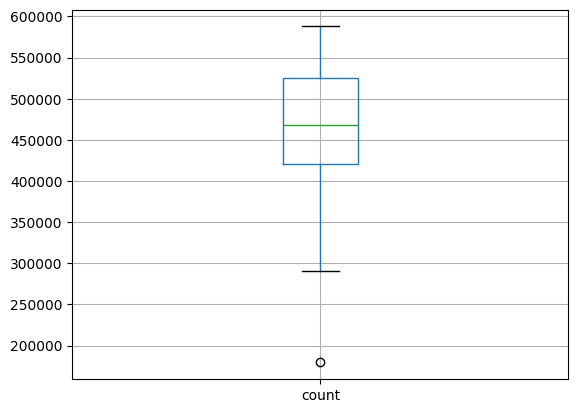

In [54]:
df_events_by_decade.boxplot()

In [96]:
mean = df_events_by_decade.describe().loc['mean'].iloc[0]
std = df_events_by_decade.describe().loc['std'].iloc[0]

In [97]:
IQR = 1.5 * std

In [98]:
(mean - IQR, mean + IQR)

(np.float64(263669.01861870533), np.float64(631036.7995631129))

In [99]:
df_events_by_decade

,count
decade,
1920s,290620
1930s,398835
1940s,587836
1950s,560584
1960s,467557
1970s,443545
1980s,474236
1990s,490650
2000s,455033


In [104]:
# find outliers: count is less than mean - IQR
df_events_by_decade[df_events_by_decade['count'] < (mean - IQR)]

,count
decade,
2020s,179505


In [105]:
# find outliers: count is greater than mean + IQR
df_events_by_decade[df_events_by_decade['count'] > (mean + IQR)]

,count
decade,


## Indexes and merging

In [113]:
textent_metadata_df.author.is_unique

False

In [114]:
textent_metadata_df.document_id.is_unique

True

In [115]:
textent_metadata_df.set_index('document_id', inplace=False)

,author,title,annotated,exclude,keep_fine_tuning,publication_date,document_length,link,link_OCR,notes
document_id,,,,,,,,,,
bpt6k5745752g,"Boissin de Gallardon, Jean",Les tragédies et histoires saintes de Jean Boi...,False,True,False,1618,338338,http://catalogue.bnf.fr/ark:/12148/cb30122385g,https://github.com/TextEnt/chrono-spatial-proc...,NaN
bpt6k5752605t,"Hauteroche, Noël Lebreton",Les bourgeoises de qualité . Comedie. Par Mr d...,True,False,False,1691,103493,http://catalogue.bnf.fr/ark:/12148/cb30582284s,https://github.com/TextEnt/chrono-spatial-proc...,NaN
bpt6k852919x,NaN,Le Mariage de Fine-Epice. Comédie,True,False,False,1664,134035,http://catalogue.bnf.fr/ark:/12148/cb39325270g,https://github.com/TextEnt/chrono-spatial-proc...,NaN
bpt6k12804007,Molière,"Sganarelle ou le Cocu imaginaire, comédie avec...",True,False,False,1662,67710,http://catalogue.bnf.fr/ark:/12148/cb38650865b,https://github.com/TextEnt/chrono-spatial-proc...,NaN
bpt6k5772310n,"Corneille, Thomas","Ariane , tragédie. Par T. Corneille",True,False,False,1672,76240,http://catalogue.bnf.fr/ark:/12148/cb30272162g,https://github.com/TextEnt/chrono-spatial-proc...,NaN
...,...,...,...,...,...,...,...,...,...,...
bpt6k62514727,"Villiers, Claude Deschamps",Les ramonneurs. Comédie . Comédie. Par Mr de V...,True,False,False,1662,63178,NaN,https://github.com/TextEnt/chrono-spatial-proc...,NaN
bpt6k12804415,Molière,"La Critique de l'Escole des femmes, comedie. P...",True,False,False,1663,49436,NaN,https://github.com/TextEnt/chrono-spatial-proc...,NaN
bpt6k8528543,"La Motte, de.","Le Grand Magus, Tragi-Comédie",True,False,False,1656,92787,NaN,https://github.com/TextEnt/chrono-spatial-proc...,NaN


In [116]:
textent_metadata_df.set_index('document_id', inplace=True)

In [117]:
textent_annotations_df.set_index('document_id', inplace=True)

In [118]:
textent_annotations_df[['period', 'preferred_location']].merge(
    textent_metadata_df[['author', 'title']],
    left_index=True,
    right_index=True,
    how='inner'
)

,period,preferred_location,author,title
document_id,,,,
bpt6k5745752g,NaN,NaN,"Boissin de Gallardon, Jean",Les tragédies et histoires saintes de Jean Boi...
bpt6k5752605t,Early modern,Paris,"Hauteroche, Noël Lebreton",Les bourgeoises de qualité . Comedie. Par Mr d...
bpt6k852919x,Early modern,Poitiers,NaN,Le Mariage de Fine-Epice. Comédie
bpt6k12804007,Early modern,Paris,Molière,"Sganarelle ou le Cocu imaginaire, comédie avec..."
bpt6k5772310n,Ancient Greece,Naxos,"Corneille, Thomas","Ariane , tragédie. Par T. Corneille"
...,...,...,...,...
bpt6k62514727,Early modern,Paris,"Villiers, Claude Deschamps",Les ramonneurs. Comédie . Comédie. Par Mr de V...
bpt6k12804415,Early modern,Paris,Molière,"La Critique de l'Escole des femmes, comedie. P..."
bpt6k8528543,Early modern,Paris,"La Motte, de.","Le Grand Magus, Tragi-Comédie"


## ⏰ ✏️ Excercise

- Work with the dataframe `textent_metadata_df`
- Plot the distribution of the number of words in each document (`document_length`)
- Is the distribution normal? What type of distribution it resembles?
- How any documents are outliers with respect to their length? Print their ID and title

## `pandas`' data structures

### `Series`

In `pandas`, series are the building blocks of dataframes.

Think of a series as a column in a table. A series collects *observations* about a given *variable*. 

In [ ]:
from random import random
import pandas as pd
import numpy as np

#### Numerical series

In [ ]:
# let's create a series containing 100 random numbers
# ranging between 0 and 1

s = pd.Series([random() for n in range(0, 100)])

Each observation in the series has an **index** as well as a set of **values**: they can be accessed via the omonymous properties:

In [ ]:
s.index

In [ ]:
list(s.index)

In [ ]:
s.values

The `head()` and `tail()` methods allows for looking at the begininning and end of a series:

In [ ]:
s.head()

In [ ]:
s.tail()

The `value_counts()` method returns a count of distinct values within a series.

In [ ]:
s.value_counts()

Is there any number in `s` that occurs twice?

In [ ]:
# a `Series` can be easily cast into a list

list(s.value_counts()).count(1)

Another way of verifying this:

In [ ]:
s.is_unique

In [ ]:
s.min()

In [ ]:
s.max()

In [ ]:
s.mean()

In [ ]:
s.median()

#### Datetime series

In [ ]:
from random import randint

In [ ]:
# let's generate a list of random dates
# in the range 1900-1950

dates = [
    pd.Timestamp(
        year,
        randint(1, 12),
        randint(1, 28) # try replacing with 31 and see what happens
    )
    for year in range(1900,1950)
]

In [ ]:
s1 = pd.Series(dates)

In [ ]:
s1

In [ ]:
type(s1[1])

In [ ]:
s1[1].day_name()

In [ ]:
s1.min()

In [ ]:
s1.max()

In [ ]:
s1.mean()

### `DataFrame`


What is a `pandas.DataFrame`? Think of it as an in-memory spreadsheet that you can analyse and manipulate programmatically.

A `DataFrame` is a collection of `Series` having the same length and whose indexes are in sync. A *collection* means that each column of a dataframe is a series

Let's create a toy `DataFrame` by hand. 

## Data manipulation in `pandas`

### Data types

String, datetimes (see above), categorical data.

In `pandas`, categories behave very much like string, yet they lead to better performances (faster operations, optimized storage).

Bottom-up approach:

In [ ]:
# transforms a Series with strings into categories
# similar to R factors

toy_df.event.astype('category')

Top-down approach:

In [ ]:
# here the list of categories is defined beforehand

from pandas.api.types import CategoricalDtype

cat_type = CategoricalDtype(
    categories=["flood", "fire", "car_crash", "earth_quake", "plane_crash"],
    ordered=True
)

toy_df.event = toy_df.event.astype(cat_type)

In [ ]:
toy_df.info()

In [ ]:
toy_df

**Question**: what happens if you remove e.g. "plane_crash" from the list `categories`? Can you explain why?

##### How are categories represented?

In [ ]:
toy_df.event.cat.codes

In [ ]:
toy_df.event.cat.categories

In [ ]:
toy_df.event = toy_df.event.cat.rename_categories({"plane_crash": "airplane_crash"})

In [ ]:
toy_df.head()

In [ ]:
toy_df.event = toy_df.event.cat.rename_categories({"airplane_crash": "plane_crash"})

In [ ]:
toy_df.head()

### Accessor properties

For certain data types (string, datetime), `pandas` provides a number of common methods that can be called on any series containing values of that type. These methods become available as methods of the series itself within a property — called *accessor* — named after the data type:

- the `.dt.*` accessor contains methods to operate on `datetime` series
- the `str.` accessor contains methods to operate on `str` (string) series.

As you will see in a moment, these methods are very convenient when filtering rows of a dataset based on the value of a certain column.

#### `datetime` accessor

To work with datetime series `pandas` provide a bunch of useful methods to operate on a series: they can be called from the `.dt` property of a datetime series.

They can be used to:
- convert from one timezone to another
- get the day/day name/month/year information from each date
- and much more (see the [documentation]())

In [ ]:
s1.head()

In [ ]:
s1.dt.day_of_week.head()

#### `str` accessor

In [ ]:
s = Series(["One", "TWO", "tHrEE"])

Accessors can be used to apply filters to a series by verifying whether a certain condition is verified or not, such is the case with `contains()`. Such methods will output a boolean value (`True` or `False`).

In [ ]:
s.str.contains('o')

In [ ]:
s.str.contains('O')

Other methods can be used, instead, to manipulate an entire series, e.g. `lower()` and `upper()`.

In [ ]:
s.str.lower()

### Exploring a dataframe

Exploring a dataframe: `df.head()`, `df.tail()`, `df.info()`.

The method `info()` gives you information about a dataframe:
- how much space does it take in memory?
- what is the datatype of each column?
- how many records are there?
- how many `null` values does each column contain (!)?

In [ ]:
toy_df.info()

Alternatively, if you need to know only the number of columns and rows you can use the `.shape` property.

It returns a tuple with 1) number of rows, 2) number of columns.

In [ ]:
toy_df.shape

Calling `len()` on a DataFrame is equivalent to `df.shape[0]`:

In [ ]:
len(toy_df)

The `.size()` method, however, is not equivalent to `len()` and `shape[0]` as it returns the number of **values**:

In [ ]:
toy_df.size

`head()` prints by first five rows of a dataframe:

In [ ]:
toy_df.head()

But the number of lines displayed is a parameter that can be changed:

In [ ]:
toy_df.head(2)

`tail()` does the opposite, i.e. prints the last n rows in the dataframe:

In [ ]:
toy_df.tail()

### Working with columns

#### Exploring values

In [ ]:
garzoni_df.head(5)

In [ ]:
garzoni_df.a_profession.value_counts()

In [ ]:
garzoni_df.annual_salary.value_counts()

Mind that `.value_counts` automatically disregards `NaN`s, unless you explicitly opt to keep them.

In [ ]:
garzoni_df.annual_salary.value_counts(dropna=False)

In [ ]:
garzoni_df.shape

#### Missing values

The series' methods `isna()` and `notna()` can be used as a way of filtering rows containing missing values (`NaN`).

In [ ]:
garzoni_df[garzoni_df.annual_salary.isna()].shape

In [ ]:
garzoni_df[garzoni_df.annual_salary.notna()].shape

The method DataFrame's method `dropna()` is used to remove rows containing missing values in any of the columns or on a selection.

In [ ]:
garzoni_df.dropna().shape

In [ ]:
garzoni_df.dropna(subset=['annual_salary']).shape

#### Casting

We call *casting* the operation of changing the act of changing the data type of one or more variables.

In [ ]:
# we define a string with value "10"
number_str = "10"

In [ ]:
# we change its type from string (`str`)
# to integeer (`int`). This is call casting

number_int = int(number_str)

In [ ]:
# the types of the two variable are different indeed

type(number_str) == type(number_int)

`pandas` objects like `Series` and `DataFrame` provide the method `astype()` to apply casting on their contents.

In [ ]:
garzoni_df.head(3)

To cast the type of the `profession_cat` column, we can use directly the `astype()` method of the Series: 

In [ ]:
professions = garzoni_df.profession_cat.astype('category')

In [ ]:
professions.cat.categories

Another way of doing this while operating on the dataframe is to use the dataframe's `astype()`:

In [ ]:
from pandas.api.types import CategoricalDtype

In [ ]:
profession_cat_type = CategoricalDtype(
    categories=garzoni_df.profession_cat[garzoni_df.profession_cat.notnull()].unique()
)

In [ ]:
garzoni_df = garzoni_df.astype(
    {
        "profession_cat": profession_cat_type
    }
)

In [ ]:
garzoni_df.profession_cat.value_counts()

#### Adding columns

Let's go back to our toy dataframe:

In [ ]:
toy_df.head()

Using the column selector with the name of a column that does not exist yet will add the effect of setting the values of all rows in that column to the value specified.

In [ ]:
toy_df['country'] = "UK"

In [ ]:
toy_df.head(3)

But if the column already exists, its value is reset:

In [ ]:
toy_df['country'] = "USA"

In [ ]:
toy_df.head(3)

#### Removing columns

The double square bracket notation ``[[...]]`` returns a dataframe having only the columns specified inside the inner brackets.

This said, removing a column is done by unselecting it:

In [ ]:
# here we removed the column country 

toy_df2 = toy_df[['date', 'count', 'event']]

In [ ]:
# it worked!

toy_df2.head()

Or using the `.drop` method like this:

In [ ]:
toy_df.drop(columns=['country'])

#### Setting a column as index

In [ ]:
toy_df.set_index('date')

In [ ]:
toy_df.head(3)

In [ ]:
toy_df.set_index('date', inplace=True)

In [ ]:
toy_df.head(3)

**Q**: can you explain the effect of the `inplace` parameter by looking at the cells above?

### Accessing data

 .loc, .iloc, slicing, iteration over rows

In [ ]:
toy_df.head(3)

#### Label-based indexing

In [ ]:
toy_df.loc['1980':'1982']

#### Integer-based indexing

In [ ]:
# select a single row, the first one

toy_df.iloc[0]

In [ ]:
# select  a range of rows by index

toy_df.iloc[[1,3,-1]]

In [ ]:
# select  a range of rows with slicing

toy_df.iloc[0:5]

In [ ]:
toy_df.index

#### Iterating over rows

In [ ]:
for index, row in toy_df.iterrows():
    print(index)

In [ ]:
for index, row in toy_df.iterrows():
    print(index, row.event)

In [ ]:
toy_df

## ⏰ ✏️ Time to practice  

**Dataset**

For this excercise we will be working with one of the datasets published by the [*Shakespeare and Company project*](https://shakespeareandco.princeton.edu/) – the *books dataset* – which can be downloaded from the following address: https://dataspace.princeton.edu/bitstream/88435/dsp01jm214s28p/2/SCoData_books_v1.2_2022-01.csv (file size = 1.34 MB)
 
**Steps**

Perform the following steps on the dataset:
- load it into a pandas' dataframe
- how many records does it contain?
- keep only the following columns: `uri`, `format` and `borrow_count`
- remove all rows where `format` value is `NaN`
- how many records does it contain now?

**Try to answer the following questions**

- What's the format(s) of the **most borrowed** document(s)? How many times was it/where they borrowed?
- What's the format(s) of the **least borrowed** document(s)? How many times was it/where they borrowed?
